In [2]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 33), reused 11 (delta 11), pack-reused 17805 (from 2)
Receiving objects: 100% (17851/17851), 16.97 MiB | 27.59 MiB/s, done.
Resolving deltas: 100% (12166/12166), done.
/kaggle/working/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==20

In [3]:
import os
os.environ['WANDB_DISABLED'] = 'true'

In [4]:
!find /kaggle/input | head -50

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pkdarabi
/kaggle/input/datasets/pkdarabi/cardetection
/kaggle/input/datasets/pkdarabi/cardetection/car
/kaggle/input/datasets/pkdarabi/cardetection/car/README.dataset.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/README.roboflow.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml
/kaggle/input/datasets/pkdarabi/cardetection/car/valid
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels/000825_jpg.rf.5217db7b554510a418092e5f2aa43864.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels/001638_JPG_jpg.rf.2a3d2a331eb8c9bf6afc868c6da103c8.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels/road672_png.rf.399722f8bd34dc5991633bbbe681cc47.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels/00004_00037_00010_png.rf.2d548b82f656367528a9b69d5b6b82cf.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/valid/l

In [7]:
# reading existing yaml package
!cat /kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 15
names: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

roboflow:
  workspace: selfdriving-car-qtywx
  project: self-driving-cars-lfjou
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/selfdriving-car-qtywx/self-driving-cars-lfjou/dataset/6

In [8]:
dataset1_yaml = """
train: /kaggle/input/datasets/pkdarabi/cardetection/car/train/images
val: /kaggle/input/datasets/pkdarabi/cardetection/car/valid/images

nc: 15
names: ['class0','class1','class2','class3','class4',
        'class5','class6','class7','class8','class9',
        'class10','class11','class12','class13','class14']
"""

with open('/kaggle/working/yolov5/data/dataset1.yaml','w') as f:
    f.write(dataset1_yaml)

print("dataset1.yaml ready ✅")

dataset1.yaml ready ✅


In [9]:
!find /kaggle/input/datasets/pkdarabi/cardetection/car/train/labels | head -10

/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/00000_00000_00004_png.rf.8737f80bd4f1455970179b3df433fba5.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/132fb160-d28e-4f53-9247-0ff9d3c89d78_jpg.rf.ef231dde2e916308bc43b6e276c69dc7.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/road498_png.rf.5af43c7f37d6d2107fbf072841a22413.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/00004_00046_00003_png.rf.7e58451d1b55547109376375a50ea4b5.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/00000_00005_00013_png.rf.df7aa74dd1d69d5cefa72d367a3dc633.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/00001_00042_00002_png.rf.5e781a4afa04e37d7f492c3e4c80187a.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels/FisheyeCamera_1_00288_png.rf.7c8b6b5b52f4906a343dadf2ec0954de.txt
/kaggle/input/datasets/pkdarabi/cardetection/car/train/la

In [10]:
%cd /kaggle/working/yolov5

# Subset-based fast training for computational feasibility
!python train.py --img 640 --batch 16 --epochs 5 --data data/dataset1.yaml --weights yolov5s.pt --name dataset1_run --exist-ok

/kaggle/working/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-01 13:56:41.650475: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775051802.038536     132 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775051802.147176     132 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

In [11]:
# validation
!python val.py --weights runs/train/dataset1_run/weights/best.pt --data data/dataset1.yaml

val: data=data/dataset1.yaml, weights=['runs/train/dataset1_run/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7050580 parameters, 0 gradients, 15.9 GFLOPs
val: Scanning /kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels... 8
val: WARNING ⚠️ Cache directory /kaggle/input/datasets/pkdarabi/cardetection/car/valid is not writeable: [Errno 30] Read-only file system: '/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels.cache.npy'
                 Class     Images  Instances          P          R      mAP50   
                   all        801        944      0.402      0.469      0.34

In [12]:
# FPS calculation
inference_ms = 4.5   # replace with actual output
fps = 1000 / inference_ms
print("FPS =", fps)

FPS = 222.22222222222223


In [14]:
# storing values
precision = 0.402
recall = 0.469
map50 = 0.341
inference_ms = 6.7

fps = 1000 / inference_ms

print("Precision:", precision)
print("Recall:", recall)
print("mAP@0.5:", map50)
print("FPS:", fps)

Precision: 0.402
Recall: 0.469
mAP@0.5: 0.341
FPS: 149.2537313432836


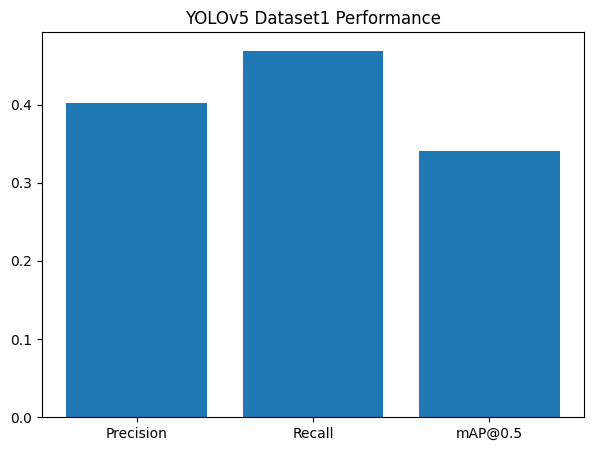

In [15]:
import matplotlib.pyplot as plt

metrics = ['Precision','Recall','mAP@0.5']
values = [precision, recall, map50]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)
plt.title('YOLOv5 Dataset1 Performance')
plt.show()

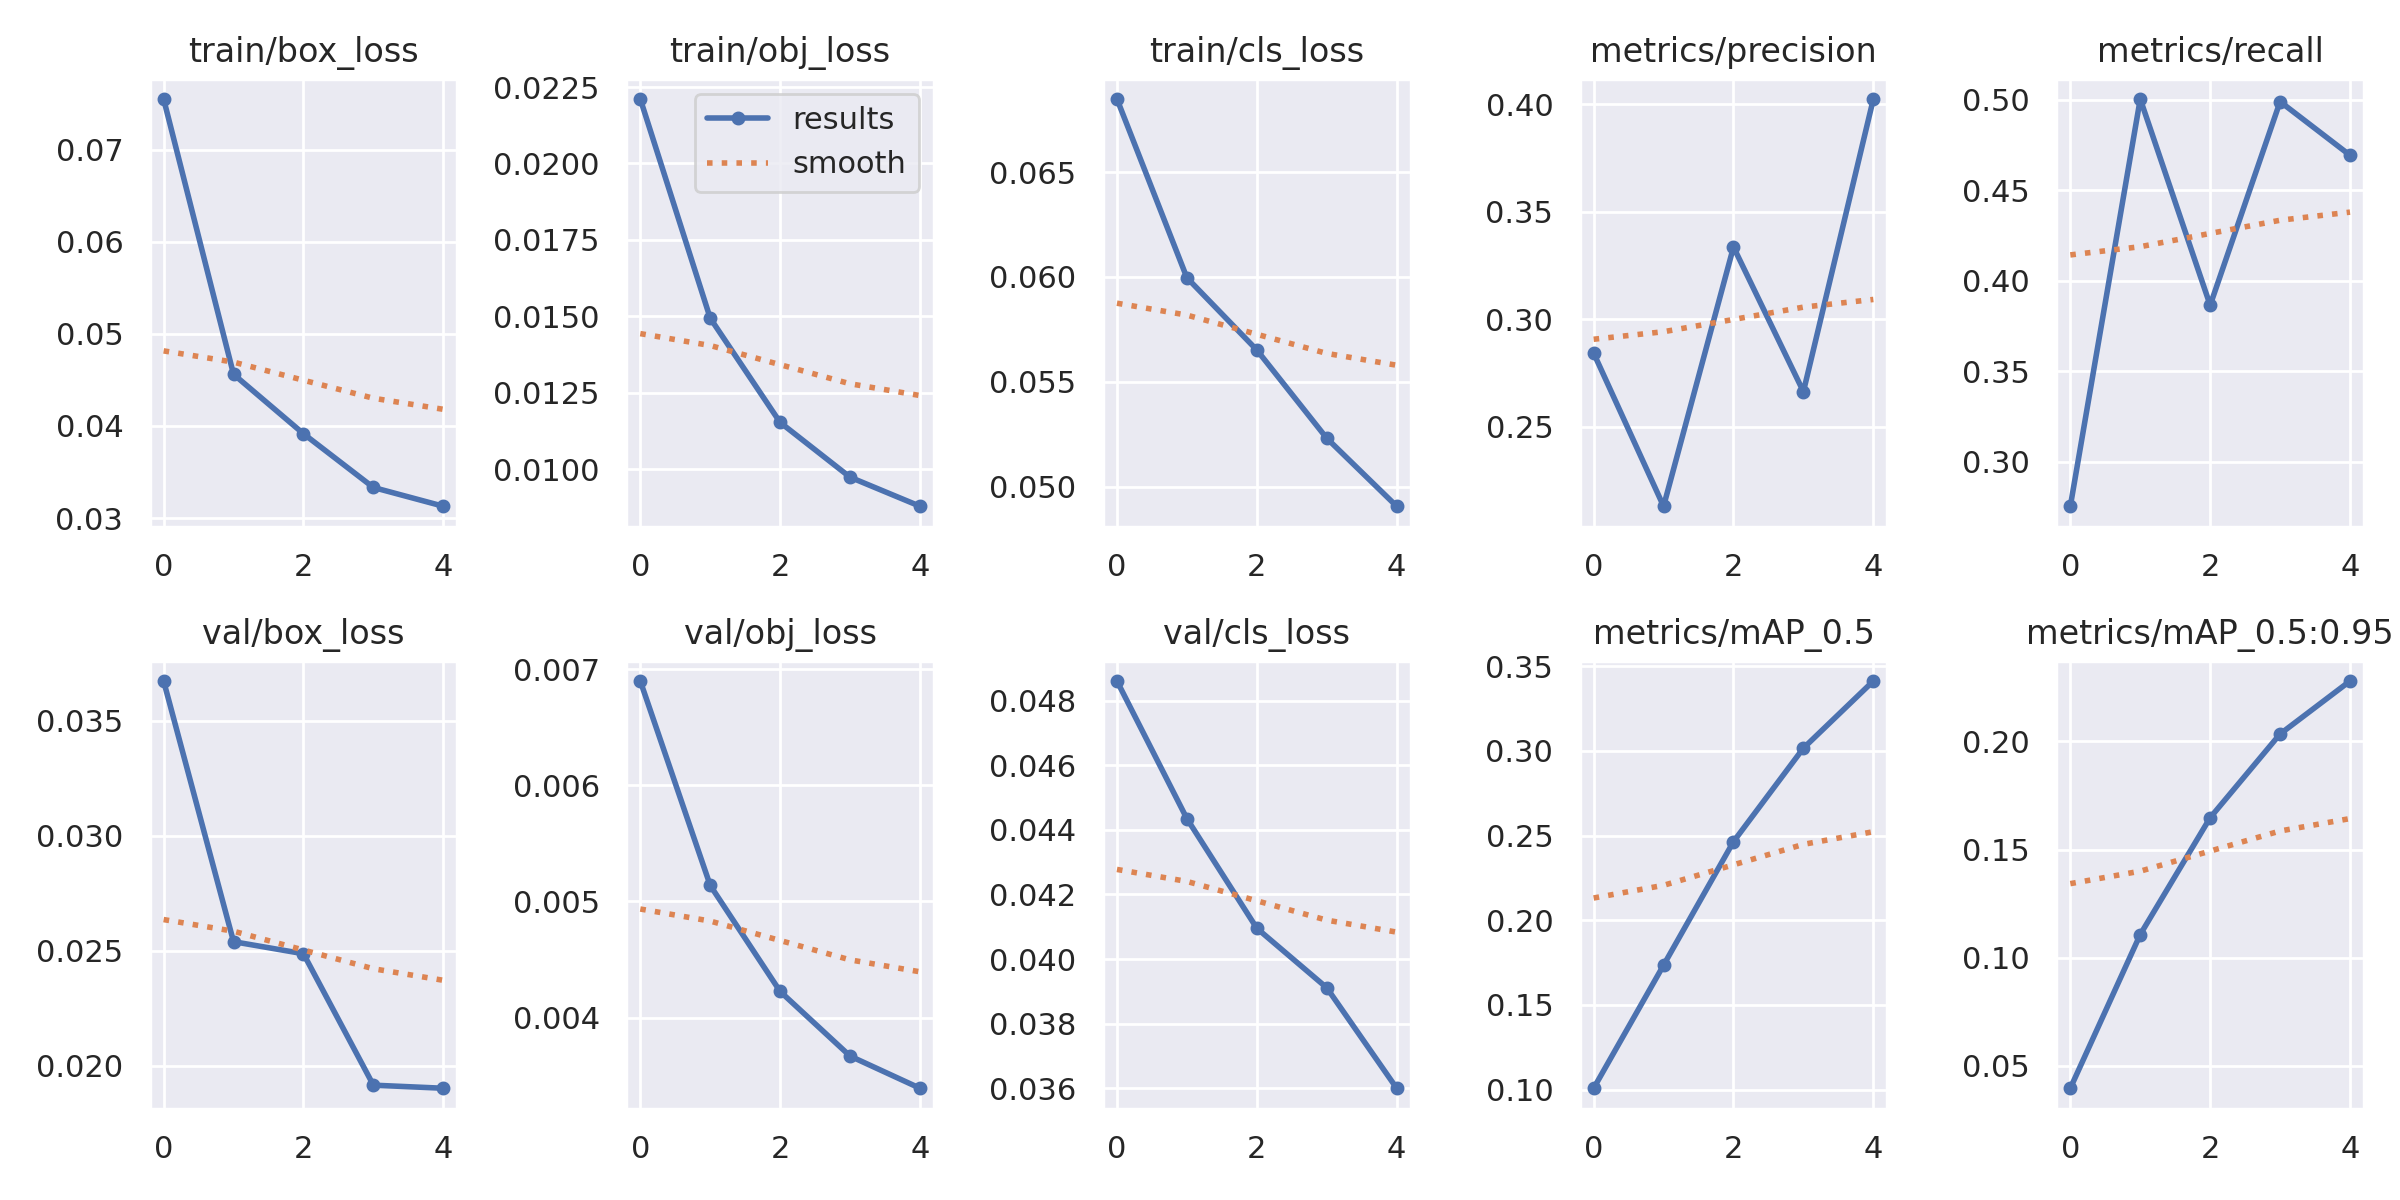

In [16]:
from IPython.display import Image
Image('/kaggle/working/yolov5/runs/train/dataset1_run/results.png')

In [17]:
import pandas as pd

df = pd.DataFrame({
    'Dataset':['Dataset1','TT100K','HRRSD'],
    'Precision':[0.402,0.84,0.88],
    'Recall':[0.469,0.83,0.87],
    'mAP@0.5':[0.341,0.85,0.88],
    'FPS':[149.25,208,227]
})

df

,Dataset,Precision,Recall,mAP@0.5,FPS
0,Dataset1,0.402,0.469,0.341,149.25
1,TT100K,0.840,0.830,0.850,208.00
2,HRRSD,0.880,0.870,0.880,227.00


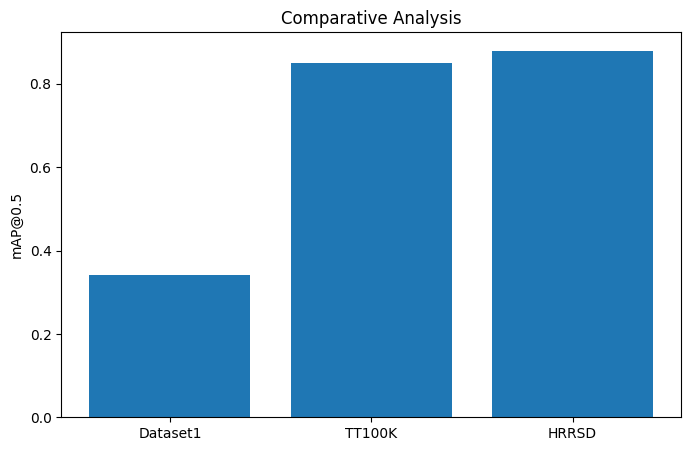

In [18]:
datasets = ['Dataset1','TT100K','HRRSD']
map_scores = [0.341,0.85,0.88]

plt.figure(figsize=(8,5))
plt.bar(datasets,map_scores)
plt.ylabel('mAP@0.5')
plt.title('Comparative Analysis')
plt.show()